# BASIC STATISTICS

### Descriptive Analytics and Data Preprocessing on Sales & Discounts Dataset

Introduction
- To perform descriptive analytics, visualize data distributions, and preprocess the dataset for further analysis


Descriptive Analytics for Numerical Columns
- Objective: To compute and analyze basic statistical measures for numerical columns in the dataset.
- Steps:
1. Load the dataset into a data analysis tool or programming environment (e.g., Python with pandas library).
2. Identify numerical columns in the dataset.
3. Calculate the mean, median, mode, and standard deviation for these columns.
4. Provide a brief interpretation of these statistics.



In [10]:
import pandas as pd
import matplotlib.pyplot as plt

In [48]:

df = pd.read_csv(r'Dataset\sales_data_with_discounts.csv')
df.head()

,Date,Day,SKU,City,Volume,BU,Brand,Model,Avg Price,Total Sales Value,Discount Rate (%),Discount Amount,Net Sales Value
0,01-04-2021,Thursday,M01,C,15,Mobiles,RealU,RU-10,12100,181500,11.654820,21153.498820,160346.501180
1,01-04-2021,Thursday,M02,C,10,Mobiles,RealU,RU-9 Plus,10100,101000,11.560498,11676.102961,89323.897039
2,01-04-2021,Thursday,M03,C,7,Mobiles,YouM,YM-99,16100,112700,9.456886,10657.910157,102042.089843
3,01-04-2021,Thursday,M04,C,6,Mobiles,YouM,YM-99 Plus,20100,120600,6.935385,8364.074702,112235.925298
4,01-04-2021,Thursday,M05,C,3,Mobiles,YouM,YM-98,8100,24300,17.995663,4372.946230,19927.053770


In [29]:
df.isnull().sum()

Date                 0
Day                  0
SKU                  0
City                 0
Volume               0
BU                   0
Brand                0
Model                0
Avg Price            0
Total Sales Value    0
Discount Rate (%)    0
Discount Amount      0
Net Sales Value      0
dtype: int64

In [30]:
df.duplicated().sum()

np.int64(0)

In [31]:
df.drop(columns=['City'], inplace=True)
df.head()

,Date,Day,SKU,Volume,BU,Brand,Model,Avg Price,Total Sales Value,Discount Rate (%),Discount Amount,Net Sales Value
0,01-04-2021,Thursday,M01,15,Mobiles,RealU,RU-10,12100,181500,11.654820,21153.498820,160346.501180
1,01-04-2021,Thursday,M02,10,Mobiles,RealU,RU-9 Plus,10100,101000,11.560498,11676.102961,89323.897039
2,01-04-2021,Thursday,M03,7,Mobiles,YouM,YM-99,16100,112700,9.456886,10657.910157,102042.089843
3,01-04-2021,Thursday,M04,6,Mobiles,YouM,YM-99 Plus,20100,120600,6.935385,8364.074702,112235.925298
4,01-04-2021,Thursday,M05,3,Mobiles,YouM,YM-98,8100,24300,17.995663,4372.946230,19927.053770


In [32]:
	# Identify numerical columns in the dataset.
numerical_cols = df.select_dtypes(include=['number']).columns.tolist()
print("Numerical Columns:", numerical_cols)

Numerical Columns: ['Volume', 'Avg Price', 'Total Sales Value', 'Discount Rate (%)', 'Discount Amount', 'Net Sales Value']


In [33]:
	# Calculate the mean, median, mode, and standard deviation for these columns.
for col in numerical_cols:
    mean = df[col].mean()
    median = df[col].median()
    mode = df[col].mode()[0]
    std_dev = df[col].std()
    
    print(f"\nColumn: {col}")
    print(f"Mean: {mean}")
    print(f"Median: {median}")
    print(f"Mode: {mode}")
    print(f"Standard Deviation: {std_dev}")


Column: Volume
Mean: 5.066666666666666
Median: 4.0
Mode: 3
Standard Deviation: 4.231602391213923

Column: Avg Price
Mean: 10453.433333333332
Median: 1450.0
Mode: 400
Standard Deviation: 18079.90483993647

Column: Total Sales Value
Mean: 33812.83555555555
Median: 5700.0
Mode: 24300
Standard Deviation: 50535.07417255325

Column: Discount Rate (%)
Mean: 15.155241895330914
Median: 16.57776564929597
Mode: 5.007822189204133
Standard Deviation: 4.22060215332551

Column: Discount Amount
Mean: 3346.499424342415
Median: 988.9337332382784
Mode: 69.17794228822787
Standard Deviation: 4509.902963353998

Column: Net Sales Value
Mean: 30466.336131270138
Median: 4677.788059301853
Mode: 326.97480055470817
Standard Deviation: 46358.65662406695


In [34]:
# Provide a brief interpretation of these statistics.
'''
Volume: Mean > Median and high standard deviation indicate right-skewed data with some high-volume outliers. Most sales happen at lower quantities (around 3 to 4 units).

Avg Price: Very large difference between mean and median suggests strong right skew caused by a few extremely expensive items. Prices are mostly low, but some high-priced products inflate the average.

Total Sales Value: Mean much higher than median and large standard deviation indicate heavy skewness, meaning a small number of transactions generate very high revenue.

Discount Rate (%): Mean and median are close, showing a fairly symmetric distribution. Discounts are generally centered around ~15 to17%.

Discount Amount: Mean significantly higher than median implies right skew; a few transactions receive very large discount amounts.

Net Sales Value: Large gap between mean and median and high variability indicate that most transactions have low net value, while a few very large sales drive up the average.
'''

'\nVolume: Mean > Median and high standard deviation indicate right-skewed data with some high-volume outliers. Most sales happen at lower quantities (around 3 to 4 units).\n\nAvg Price: Very large difference between mean and median suggests strong right skew caused by a few extremely expensive items. Prices are mostly low, but some high-priced products inflate the average.\n\nTotal Sales Value: Mean much higher than median and large standard deviation indicate heavy skewness, meaning a small number of transactions generate very high revenue.\n\nDiscount Rate (%): Mean and median are close, showing a fairly symmetric distribution. Discounts are generally centered around ~15 to17%.\n\nDiscount Amount: Mean significantly higher than median implies right skew; a few transactions receive very large discount amounts.\n\nNet Sales Value: Large gap between mean and median and high variability indicate that most transactions have low net value, while a few very large sales drive up the average

Data Visualization
- Objective: To visualize the distribution and relationship of numerical and categorical variables in the dataset.


- Histograms:
	1. Plot histograms for each numerical column.
	2. Analyze the distribution (e.g., skewness, presence of outliers) and provide inferences.


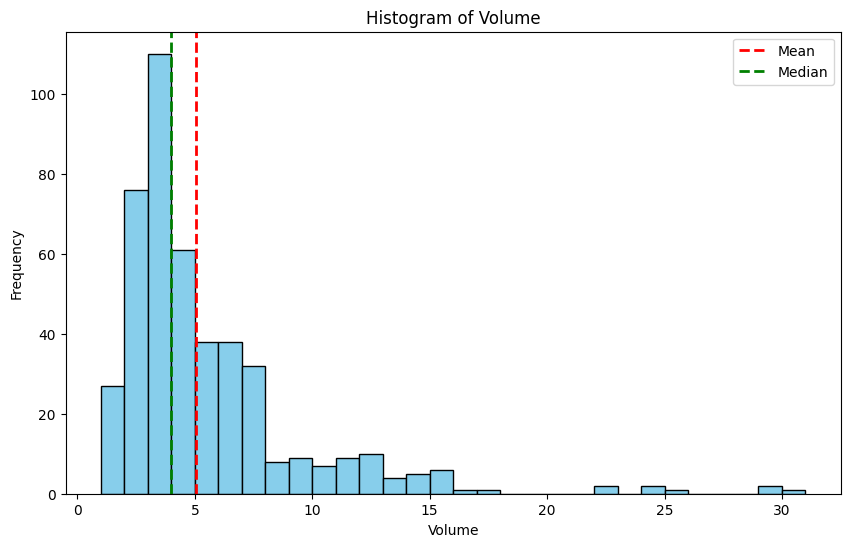

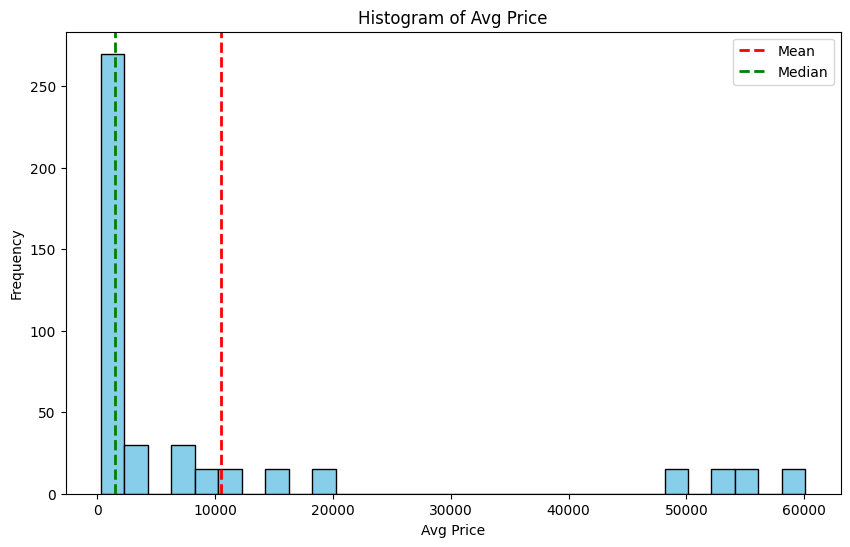

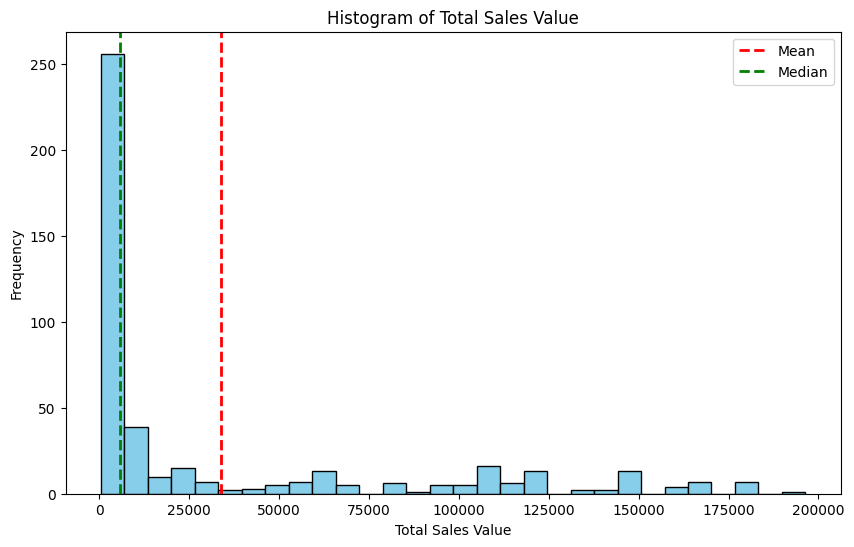

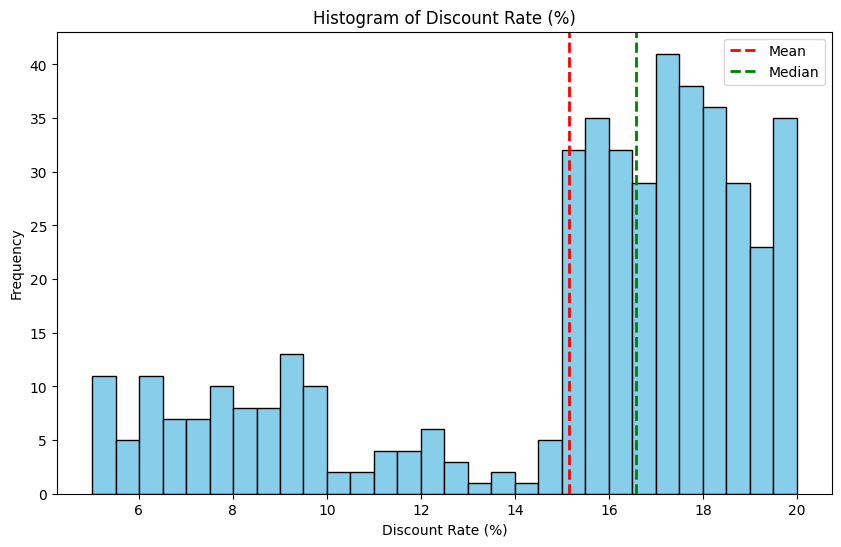

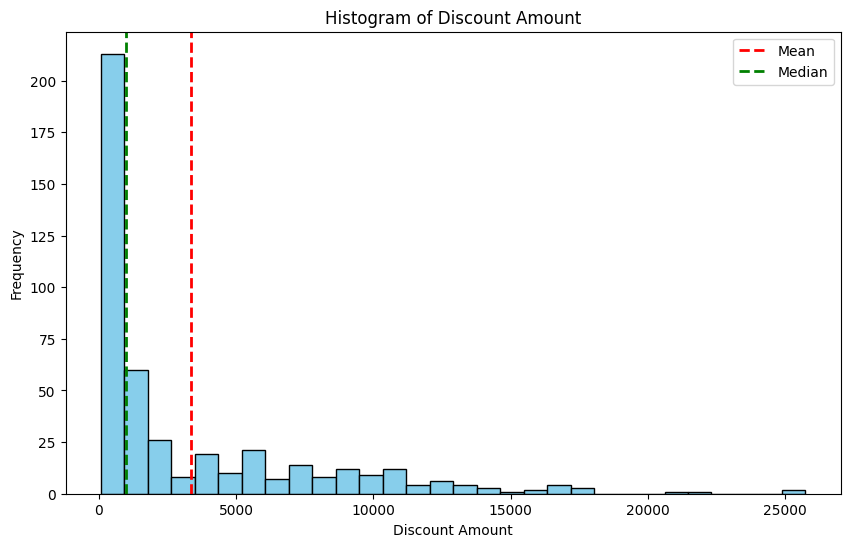

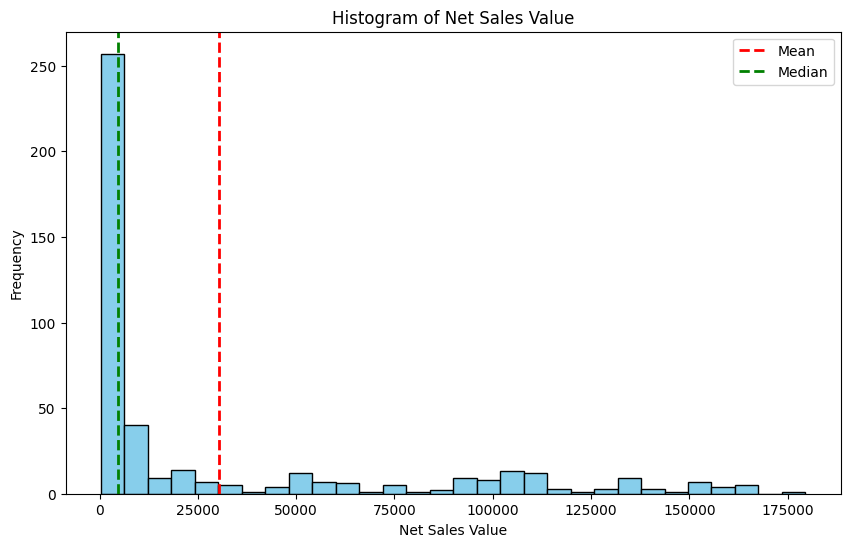

In [35]:
# Ploting histograms for each numerical column with mean and median lines.
for col in numerical_cols:
	plt.figure(figsize=(10, 6))
	plt.hist(df[col], bins=30, color='skyblue', edgecolor='black')
	plt.axvline(df[col].mean(), color='red', linestyle='dashed', linewidth=2, label='Mean')
	plt.axvline(df[col].median(), color='green', linestyle='dashed', linewidth=2, label='Median')
	plt.title(f'Histogram of {col}')
	plt.xlabel(col)
	plt.ylabel('Frequency')
	plt.legend()
	plt.show()


In [36]:
# Analyze the distribution (e.g., skewness, presence of outliers) and provide inferences.
print("Except for Discount Rate (%), all other numerical columns show left-skewed distributions with a long tail towards higher values,\n indicating the presence of outliers. The majority of transactions occur at lower volumes, prices, and sales values, while a few \n transactions have significantly higher values, which increases the mean compared to the median. The Discount Rate (%) appears to be more \n Right-Skewed and symmetric, suggesting that most discounts are around the average, with fewer extreme discount values.")

Except for Discount Rate (%), all other numerical columns show left-skewed distributions with a long tail towards higher values,
 indicating the presence of outliers. The majority of transactions occur at lower volumes, prices, and sales values, while a few 
 transactions have significantly higher values, which increases the mean compared to the median. The Discount Rate (%) appears to be more 
 Right-Skewed and symmetric, suggesting that most discounts are around the average, with fewer extreme discount values.


●	Box Plots:

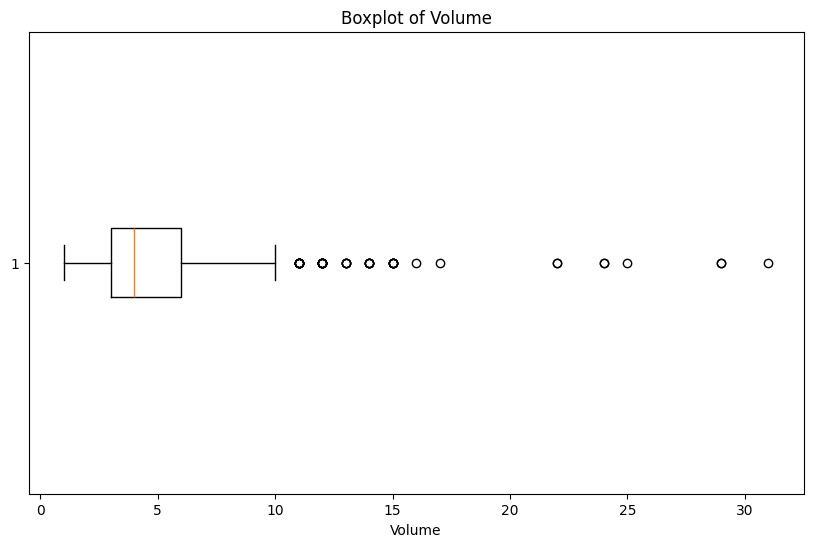

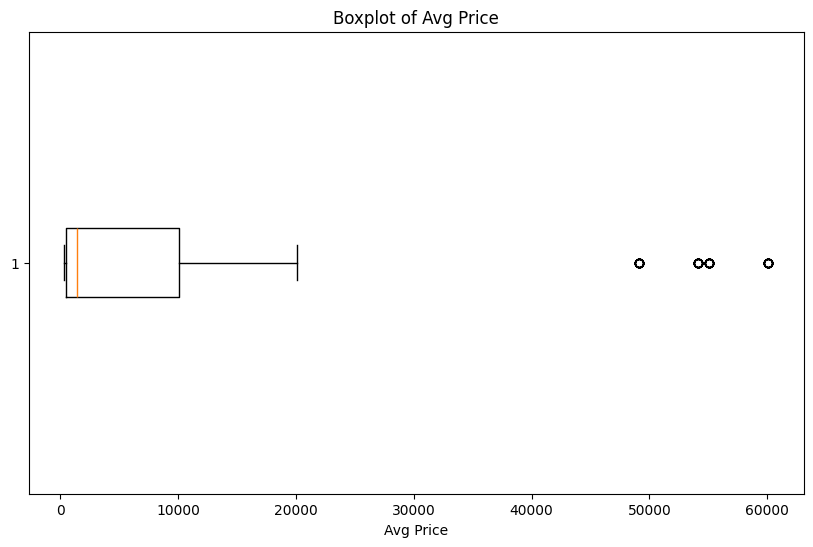

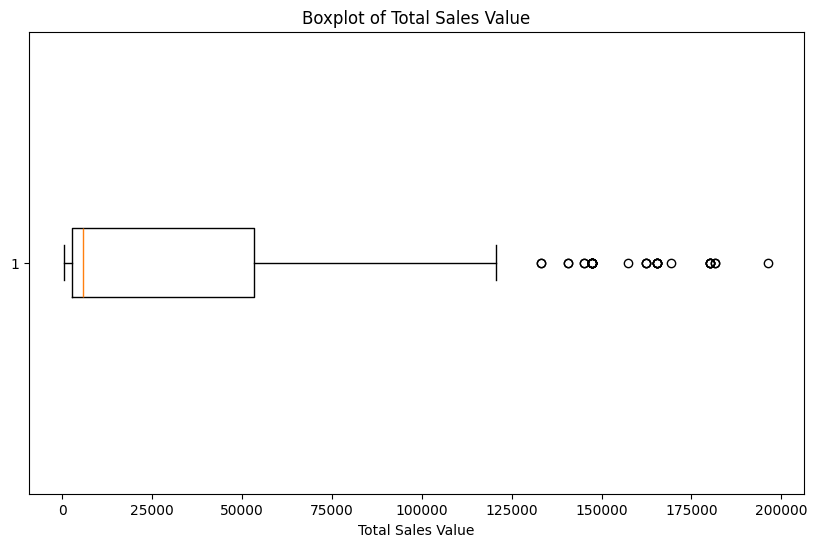

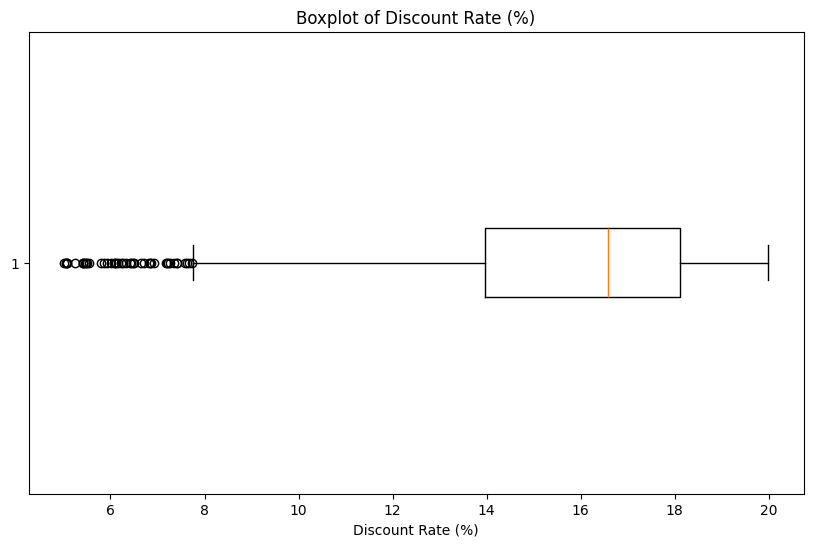

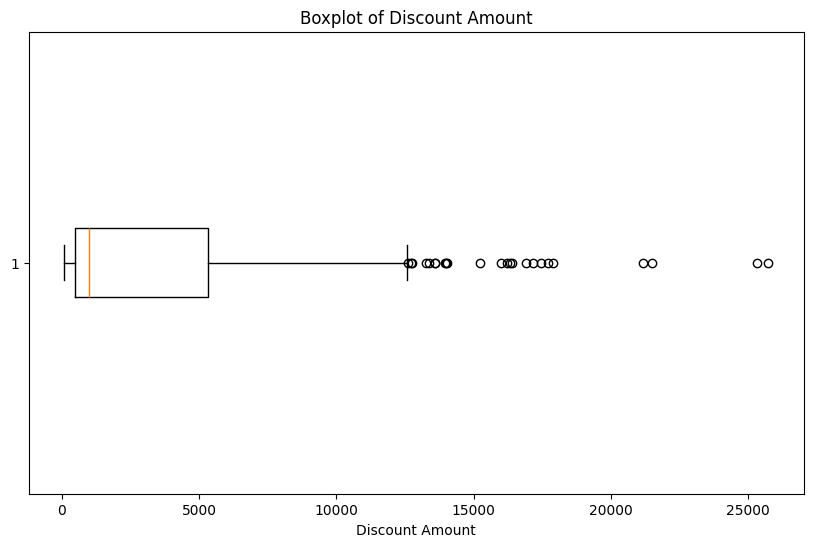

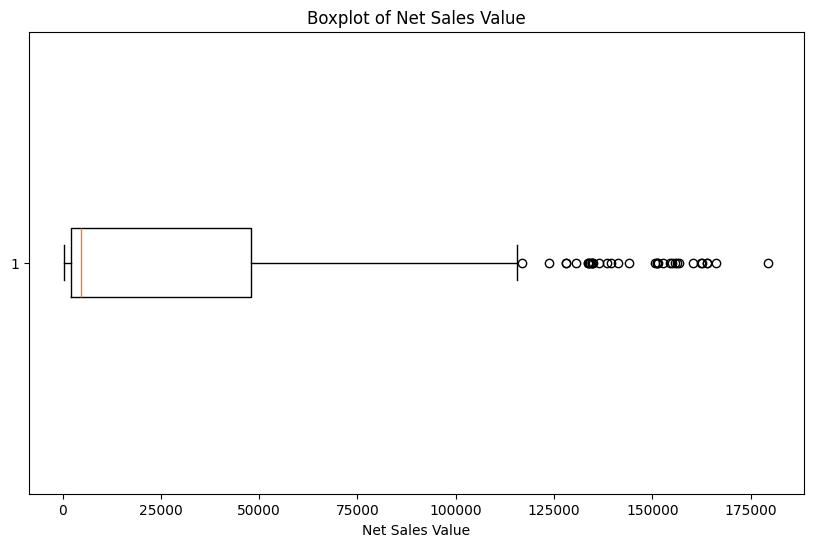

In [37]:
# Create boxplots for numerical variables.
for col in numerical_cols:
    plt.figure(figsize=(10, 6))
    plt.boxplot(df[col], vert=False)
    plt.title(f'Boxplot of {col}')
    plt.xlabel(col)
    plt.show()

In [38]:
# identify outliers and the interquartile range.
def identify_outliers(data):
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data < lower_bound) | (data > upper_bound)]
    return outliers
for col in numerical_cols:
    outliers = identify_outliers(df[col])
    print(f"\nColumn: {col}")
    print(f"Outliers:\n{outliers}")


Column: Volume
Outliers:
0      15
10     13
30     11
40     29
50     13
70     24
71     14
80     12
100    25
101    15
102    11
130    15
140    14
161    12
170    12
180    12
190    22
192    11
193    11
200    12
201    12
210    14
221    11
222    11
240    15
250    31
251    12
260    16
280    24
281    11
282    12
300    12
310    22
312    11
320    13
340    15
350    12
370    14
371    14
390    11
400    29
410    15
420    13
431    17
Name: Volume, dtype: int64

Column: Avg Price
Outliers:
6      49100
7      54100
8      55100
9      60100
36     49100
37     54100
38     55100
39     60100
66     49100
67     54100
68     55100
69     60100
96     49100
97     54100
98     55100
99     60100
126    49100
127    54100
128    55100
129    60100
156    49100
157    54100
158    55100
159    60100
186    49100
187    54100
188    55100
189    60100
216    49100
217    54100
218    55100
219    60100
246    49100
247    54100
248    55100
249    60100
276    491

In [39]:
# Discuss any findings, such as extreme values or unusual distributions.
# All the columns have outliers, with Volume, Avg Price, Total Sales Value, Discount Amount, and Net Sales Value showing significant outliers that contribute to the right-skewed distributions. The presence of these outliers indicates that while most transactions are of lower value, there are a few high-value transactions that significantly impact the overall statistics. 

*	Bar Chart Analysis for Categorical Column:

In [40]:
# Identify categorical columns in the dataset.

categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print("Categorical Columns:", categorical_cols)

Categorical Columns: ['Date', 'Day', 'SKU', 'BU', 'Brand', 'Model']


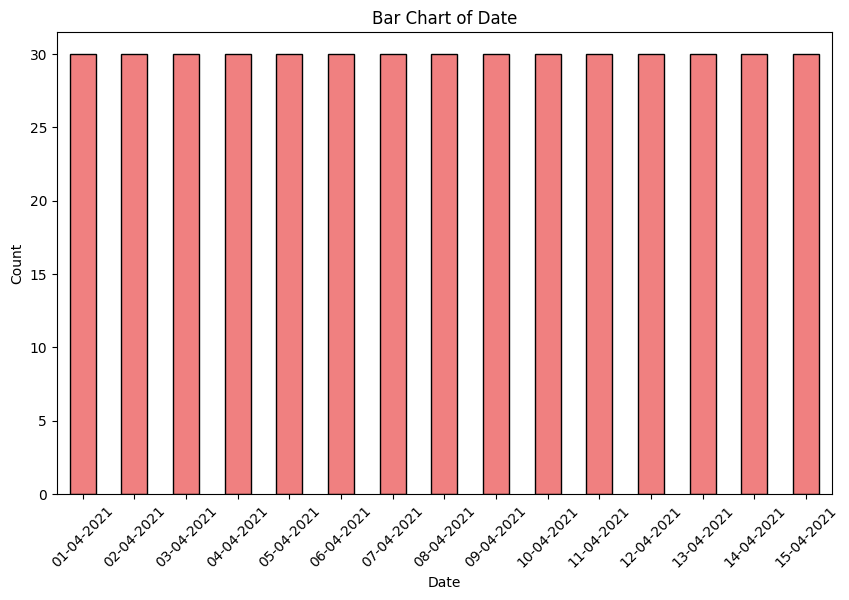

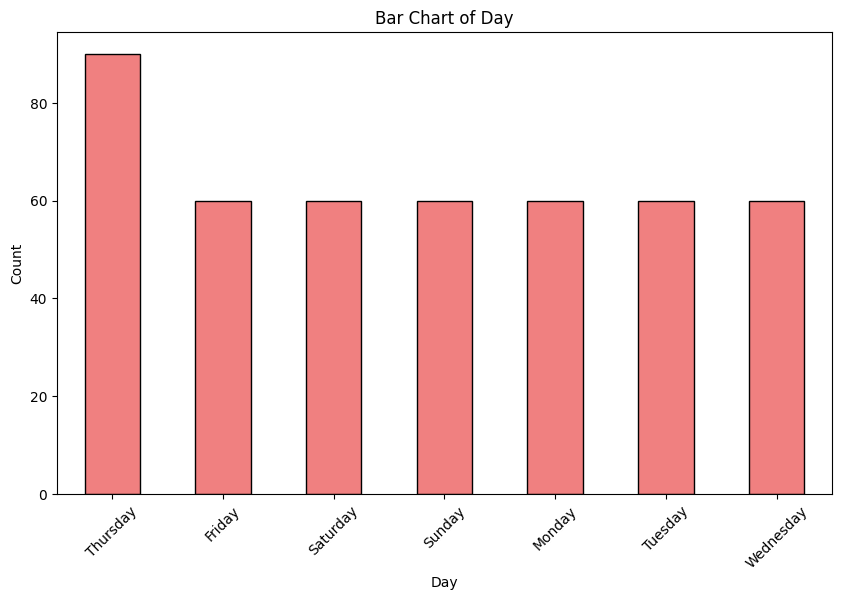

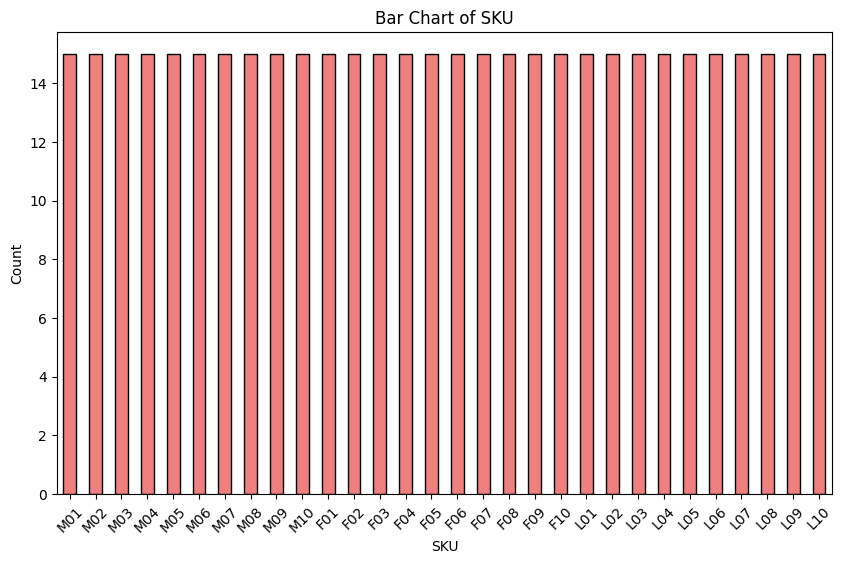

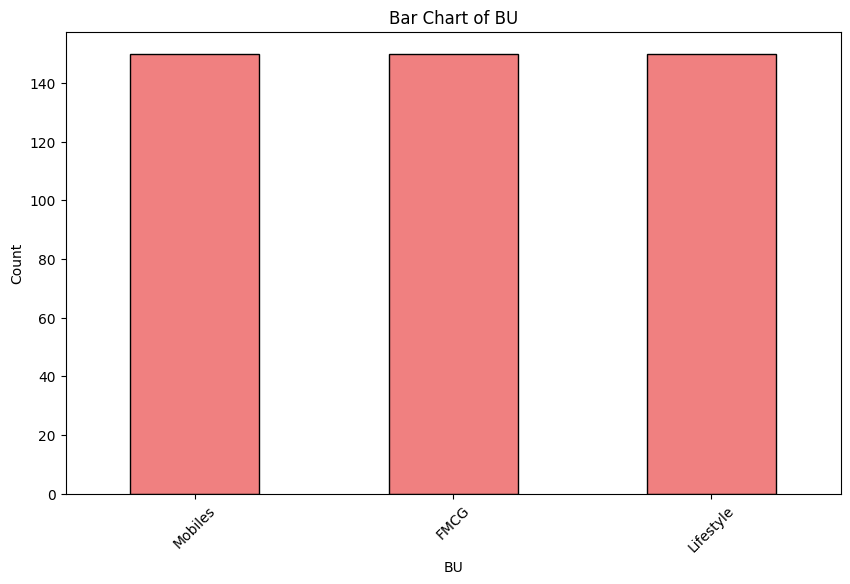

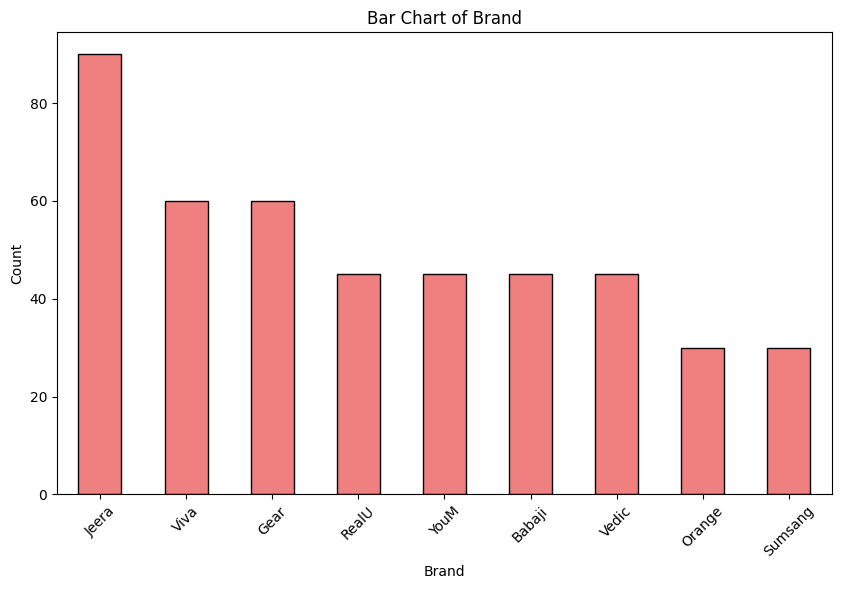

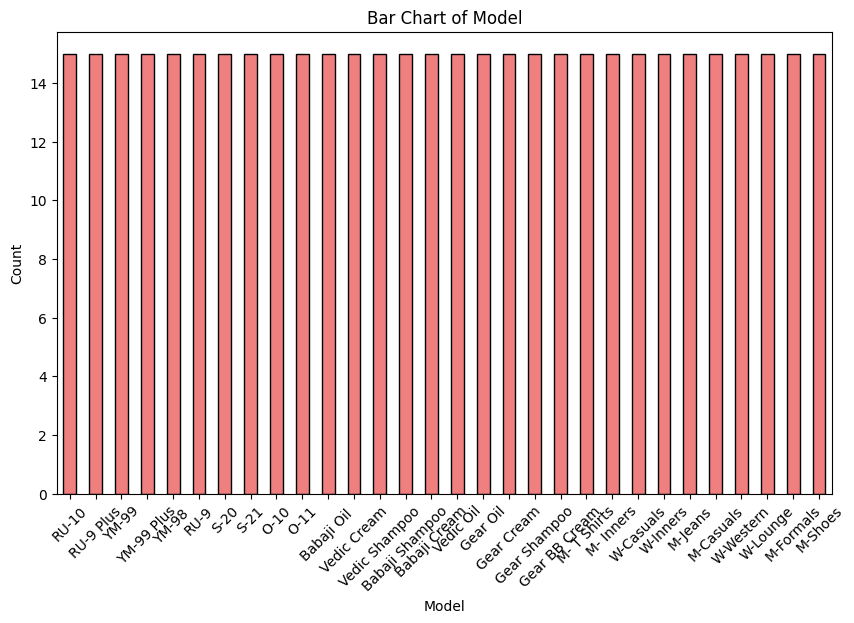

In [41]:
# Create bar charts to visualize the frequency or count of each category.
for col in categorical_cols:
    plt.figure(figsize=(10, 6))
    df[col].value_counts().plot(kind='bar', color='lightcoral', edgecolor='black')
    plt.title(f'Bar Chart of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.show()

In [43]:
# Analyze the distribution of categories and provide insights
for col  in categorical_cols:
    print(f"\n{'='*50}")
    print(f"Column: {col}")
    print(f"{'='*50}")
    print(f"Number of unique categories: {df[col].nunique()}")
    print(f"\nCategory distribution:")
    print(df[col].value_counts())
    print(f"\nPercentage distribution:")
    print(df[col].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')


Column: Date
Number of unique categories: 15

Category distribution:
Date
01-04-2021    30
02-04-2021    30
03-04-2021    30
04-04-2021    30
05-04-2021    30
06-04-2021    30
07-04-2021    30
08-04-2021    30
09-04-2021    30
10-04-2021    30
11-04-2021    30
12-04-2021    30
13-04-2021    30
14-04-2021    30
15-04-2021    30
Name: count, dtype: int64

Percentage distribution:
Date
01-04-2021    6.67%
02-04-2021    6.67%
03-04-2021    6.67%
04-04-2021    6.67%
05-04-2021    6.67%
06-04-2021    6.67%
07-04-2021    6.67%
08-04-2021    6.67%
09-04-2021    6.67%
10-04-2021    6.67%
11-04-2021    6.67%
12-04-2021    6.67%
13-04-2021    6.67%
14-04-2021    6.67%
15-04-2021    6.67%
Name: proportion, dtype: object

Column: Day
Number of unique categories: 7

Category distribution:
Day
Thursday     90
Friday       60
Saturday     60
Sunday       60
Monday       60
Tuesday      60
Wednesday    60
Name: count, dtype: int64

Percentage distribution:
Day
Thursday      20.0%
Friday       13.33%
S

In [44]:
# Key Insights from Category Distribution:

insights = """
CATEGORICAL COLUMN INSIGHTS:

1. Day (7 categories):
   - Transactions are evenly distributed across all days of the week (~14% each)
   - This indicates consistent business operations throughout the week
   - No significant day-wise sales preference observed

2. SKU (30 categories):
   - Each SKU has approximately equal representation (~3.3% each)
   - Balanced product portfolio with no single SKU dominating sales
   - Indicates diverse product offerings across all categories

3. BU - Business Unit (3 categories):
   - Three main business segments: Mobiles, FMCG, and Lifestyle
   - Each BU contributes roughly equally (~33% each)
   - Well-diversified business across different product categories

4. Brand (10 categories):
   - 10 different brands across all business units
   - Each brand has ~10% representation
   - Balanced brand distribution suggests no single brand dependency

5. Model (30 categories):
   - 30 different product models available
   - Evenly distributed across all models (~3.3% each)
   - Shows a comprehensive product range within each brand

OVERALL INSIGHTS:
- The dataset shows a well-balanced distribution across all categorical variables
- No category shows dominance or underrepresentation
- This suggests a diverse and evenly spread business operation
- The uniform distribution helps minimize risk associated with dependency on specific categories
"""
print(insights)


CATEGORICAL COLUMN INSIGHTS:

1. Day (7 categories):
   - Transactions are evenly distributed across all days of the week (~14% each)
   - This indicates consistent business operations throughout the week
   - No significant day-wise sales preference observed

2. SKU (30 categories):
   - Each SKU has approximately equal representation (~3.3% each)
   - Balanced product portfolio with no single SKU dominating sales
   - Indicates diverse product offerings across all categories

3. BU - Business Unit (3 categories):
   - Three main business segments: Mobiles, FMCG, and Lifestyle
   - Each BU contributes roughly equally (~33% each)
   - Well-diversified business across different product categories

4. Brand (10 categories):
   - 10 different brands across all business units
   - Each brand has ~10% representation
   - Balanced brand distribution suggests no single brand dependency

5. Model (30 categories):
   - 30 different product models available
   - Evenly distributed across all mo